<a href="https://colab.research.google.com/github/xm0207/Shaun-s-Project/blob/main/homework_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network for CIFAR-10 classification


In this hometask you'll implement and train neural networks for classification of images from the CIFAR-10 dataset.


CIFAR-10 is a dataset of small **color** images from 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Each image has size **32×32×3**. This makes the task harder than MNIST, because now the images are colored and the objects are much more visually diverse.


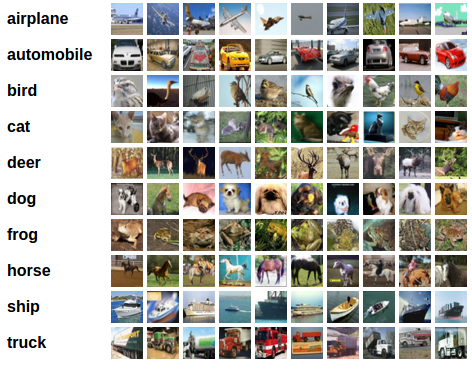

We will also visualize a few CIFAR-10 images after loading the dataset.


## Loading data


The cell below downloads CIFAR-10 using `torchvision`.


In [1]:
import torchvision
from torchvision import transforms

train_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)


100%|██████████| 170M/170M [00:07<00:00, 21.8MB/s]


After this, you'll have the CIFAR-10 training and testing splits downloaded into the `./data` directory.


Let's import NumPy, Pandas and look at our data:


In [2]:
import numpy as np
import pandas as pd

In [3]:
class_names = train_dataset_raw.classes

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In this table, each image is represented as a vector of size **32×32×3 = 3072**, where each feature corresponds to one pixel channel (Red, Green or Blue) value. Pixel values are in the range **[0, 255]**.

Column `label` is the target variable representing the image class. The class mapping is:

```python
{idx: name for idx, name in enumerate(class_names)}
```


Let's visualize the first image:


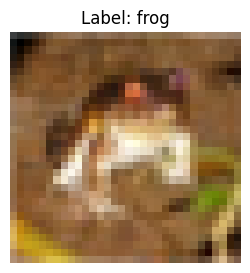

In [4]:
import matplotlib.pyplot as plt

# you can change the index and visualize different images
idx = 0
img = train_images[idx]
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Label: {class_names[train_labels[idx]]}')
plt.axis('off');

Let's also load test data:


In [5]:
# test_data has already been created above
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,158,112,49,159,111,47,165,116,51,166,...,24,77,124,34,84,129,21,67,110,3
1,235,235,235,231,231,231,232,232,232,232,...,168,183,178,180,195,191,186,200,199,8
2,158,190,222,158,187,218,139,166,194,132,...,5,6,8,4,5,3,7,8,7,8
3,155,156,149,167,176,187,176,179,193,190,...,60,63,50,64,65,52,73,68,50,0
4,65,68,50,70,81,64,48,64,46,30,...,143,179,136,154,185,146,128,156,117,6


## Task 1. Binary classification with NNs


In this first task you'll define and train a neural network for **binary classification** of CIFAR-10 images.

As we have 10 classes in the full dataset, we'll first extract parts of the data containing only two classes.

We will solve two tasks: classification of classes that usually look quite different (**airplane** vs **ship**) and classification of classes that are much easier to confuse (**cat** vs **dog**). It is interesting to see how these tasks differ in difficulty and whether different neural network architectures or hyperparameters are optimal for them.


So let's extract data for airplane/ship classification and for cat/dog classification:


In [12]:
# frog / ship classification
labels_to_train = [class_names.index('frog'), class_names.index('ship')]
train_data_frog_ship = train_data[train_data['label'].isin(labels_to_train)].copy().reset_index(drop=True)
test_data_frog_ship = test_data[test_data['label'].isin(labels_to_train)].copy().reset_index(drop=True)

# convert labels to 0/1 for binary classification
train_data_frog_ship['label'] = (train_data_frog_ship['label'] == class_names.index('ship')).astype(int)
test_data_frog_ship['label'] = (test_data_frog_ship['label'] == class_names.index('ship')).astype(int)

# divide data into features and target variable
X_train_frog_ship = train_data_frog_ship.drop(columns=['label']).reset_index(drop=True)
y_train_frog_ship = train_data_frog_ship['label'].reset_index(drop=True)
X_test_frog_ship = test_data_frog_ship.drop(columns=['label']).reset_index(drop=True)
y_test_frog_ship = test_data_frog_ship['label'].reset_index(drop=True)

In [13]:
# cat / dog classification
labels_to_train = [class_names.index('cat'), class_names.index('dog')]
train_data_cat_dog = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_cat_dog = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_cat_dog['label'] = (train_data_cat_dog['label'] == class_names.index('dog')).astype(int)
test_data_cat_dog['label'] = (test_data_cat_dog['label'] == class_names.index('dog')).astype(int)

# divide data into features and target variable
X_train_cat_dog = train_data_cat_dog.drop(columns=['label'])
y_train_cat_dog = train_data_cat_dog['label']
X_test_cat_dog = test_data_cat_dog.drop(columns=['label'])
y_test_cat_dog = test_data_cat_dog['label']


### Task 1.1. Write a neural network for binary classification


For now, write any architecture that would consume a flattened CIFAR-10 image and output the probability of class 1. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [8]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(3072, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


And create a network:


In [9]:
net = Net()

### Task 1.2. Define a train function.


You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)


In [10]:
import tqdm
from tqdm.auto import tqdm

def train(model, dataloader, criterion, optimizer, num_epoch):
    model.train()
    epoch_losses = []

    for epoch in range(num_epoch):
        running_loss = 0.0

        for x, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epoch}"):
            # flatten image
            x = x.view(x.size(0), -1)

            # make y shape compatible with output [batch_size, 1]
            y = y.float().view(-1, 1)

            # forward
            outputs = model(x)
            loss = criterion(outputs, y)

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(dataloader)
        epoch_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {avg_loss:.4f}")

    return model, epoch_losses

And let's define loss function, optimizer, dataloader and train our network. For now, use `train_data_frog_ship` to pass to the dataloader.


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# loss function
criterion = nn.BCELoss()

# optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

# dataloader
X_train_tensor = torch.tensor(X_train_frog_ship.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_frog_ship.values, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# run training
net, losses = train(net, train_loader, criterion, optimizer, 60)

Epoch 1/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/60], Loss: 49.8102


Epoch 2/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [2/60], Loss: 50.0000


Epoch 3/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [3/60], Loss: 50.1194


Epoch 4/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [4/60], Loss: 50.0597


Epoch 5/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [5/60], Loss: 49.8806


Epoch 6/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [6/60], Loss: 49.9403


Epoch 7/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [7/60], Loss: 50.0299


Epoch 8/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [8/60], Loss: 50.0896


Epoch 9/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [9/60], Loss: 49.9701


Epoch 10/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [10/60], Loss: 50.0896


Epoch 11/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [11/60], Loss: 50.0000


Epoch 12/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [12/60], Loss: 50.0299


Epoch 13/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [13/60], Loss: 50.0000


Epoch 14/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [14/60], Loss: 50.0299


Epoch 15/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [15/60], Loss: 50.0597


Epoch 16/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [16/60], Loss: 49.9701


Epoch 17/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [17/60], Loss: 50.0000


Epoch 18/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [18/60], Loss: 49.9701


Epoch 19/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [19/60], Loss: 50.0000


Epoch 20/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [20/60], Loss: 50.0299


Epoch 21/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [21/60], Loss: 50.0299


Epoch 22/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [22/60], Loss: 50.0000


Epoch 23/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [23/60], Loss: 50.0299


Epoch 24/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [24/60], Loss: 50.0896


Epoch 25/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [25/60], Loss: 49.9403


Epoch 26/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [26/60], Loss: 50.0597


Epoch 27/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [27/60], Loss: 50.0299


Epoch 28/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [28/60], Loss: 49.8806


Epoch 29/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [29/60], Loss: 49.9403


Epoch 30/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [30/60], Loss: 49.9403


Epoch 31/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [31/60], Loss: 49.9403


Epoch 32/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [32/60], Loss: 50.0299


Epoch 33/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [33/60], Loss: 50.0299


Epoch 34/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [34/60], Loss: 50.0000


Epoch 35/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [35/60], Loss: 49.8806


Epoch 36/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [36/60], Loss: 50.0299


Epoch 37/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [37/60], Loss: 49.9403


Epoch 38/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [38/60], Loss: 50.0896


Epoch 39/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [39/60], Loss: 50.0299


Epoch 40/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [40/60], Loss: 50.0299


Epoch 41/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [41/60], Loss: 50.0597


Epoch 42/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [42/60], Loss: 49.9701


Epoch 43/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [43/60], Loss: 49.9701


Epoch 44/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [44/60], Loss: 50.0000


Epoch 45/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [45/60], Loss: 49.9403


Epoch 46/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [46/60], Loss: 49.8806


Epoch 47/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [47/60], Loss: 49.9701


Epoch 48/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [48/60], Loss: 50.0299


Epoch 49/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [49/60], Loss: 50.0597


Epoch 50/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [50/60], Loss: 50.0000


Epoch 51/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [51/60], Loss: 49.8806


Epoch 52/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [52/60], Loss: 49.9701


Epoch 53/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [53/60], Loss: 49.9701


Epoch 54/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [54/60], Loss: 50.0299


Epoch 55/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [55/60], Loss: 50.0896


Epoch 56/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [56/60], Loss: 50.1194


Epoch 57/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [57/60], Loss: 49.9701


Epoch 58/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [58/60], Loss: 50.0299


Epoch 59/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [59/60], Loss: 49.9701


Epoch 60/60:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [60/60], Loss: 49.9403


### Task 1.3. Write a code for model evaluation


After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below


In [16]:
import torch
from sklearn.metrics import accuracy_score

def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''
    model.eval()

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            X_batch = X_batch.float()
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch.float().view(-1, 1))
            losses.append(loss.item())

        # convert outputs of your network into class number
        y_pred = (y_pred.squeeze() >= 0.5).long().tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = accuracy_score(y_true_list, y_pred_list)

    return np.mean(losses), accuracy

And let's evaluate our trained network on test data. Use `test_data_frog_ship` for testing.


In [17]:
X_test_tensor = torch.tensor(X_test_frog_ship.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_frog_ship.values, dtype=torch.float32)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

evaluate(net, test_loader, criterion)

(np.float64(50.5859375), 0.5)

### Task 1.4. Train the neural network to classify airplane/ship images


Now you have a network that can be trained and evaluated on binary classification data. Your task is to improve it so that your neural network can achieve **>0.94 accuracy** on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 64-256 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, number of neurons, and different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, optimizer type, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.



Training with Sigmoid...
Epoch [10/30], Loss: 0.1685
Epoch [20/30], Loss: 0.1418
Epoch [30/30], Loss: 0.1170

Training with Tanh...
Epoch [10/30], Loss: 0.2191
Epoch [20/30], Loss: 0.1752
Epoch [30/30], Loss: 0.1799

Training with ReLU...
Epoch [10/30], Loss: 0.1603
Epoch [20/30], Loss: 0.1181
Epoch [30/30], Loss: 0.0965

Test Loss: 0.1925, Test Accuracy: 0.9365


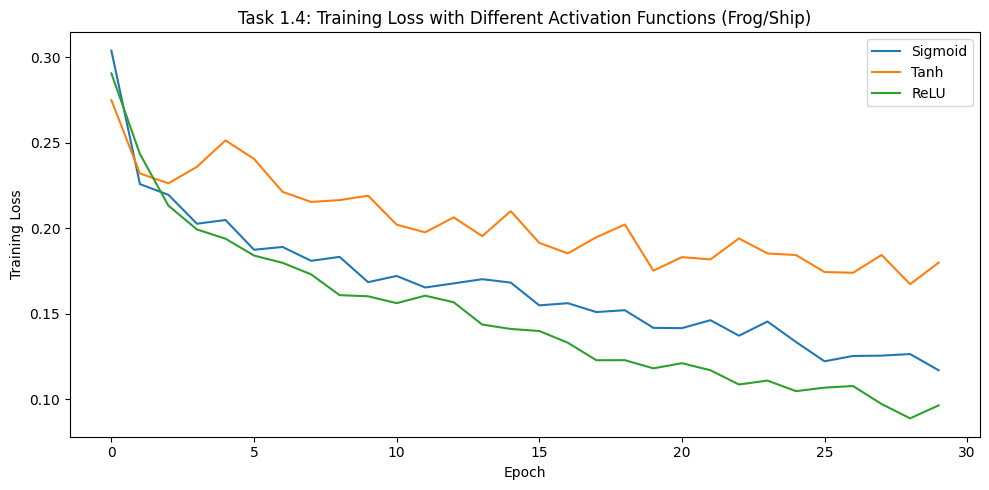


--- Findings ---
Network size: 3 hidden layers (512, 256, 128 neurons) + output layer
ReLU converges fastest and achieves lowest training loss.
Sigmoid converges very slowly due to vanishing gradients.
Tanh is between Sigmoid and ReLU in convergence speed.
Normalized pixel values (0-1) significantly improved training stability.


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ---- Normalize data to [0, 1] ----
X_train_norm = X_train_frog_ship.values / 255.0
X_test_norm = X_test_frog_ship.values / 255.0

X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train_frog_ship.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_frog_ship.values, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)
train_loader14 = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader14  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# ---- Task 1.4: Improved network for frog/ship (>0.94 accuracy) ----
class ImprovedNet(nn.Module):
    def __init__(self, activation=nn.ReLU()):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 512),
            activation,
            nn.Linear(512, 256),
            activation,
            nn.Linear(256, 128),
            activation,
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_binary(model, train_loader, criterion, optimizer, num_epoch):
    model.train()
    epoch_losses = []
    for epoch in range(num_epoch):
        running_loss = 0.0
        for x, y in train_loader:
            y = y.float().view(-1, 1)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {avg_loss:.4f}")
    return epoch_losses

# ---- Experiment with 3 activation functions ----
activations = {
    'Sigmoid': nn.Sigmoid(),
    'Tanh':    nn.Tanh(),
    'ReLU':    nn.ReLU()
}

criterion14 = nn.BCELoss()
all_losses = {}

for act_name, act_fn in activations.items():
    print(f"\nTraining with {act_name}...")
    model = ImprovedNet(activation=act_fn)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    losses = train_binary(model, train_loader14, criterion14, optimizer, num_epoch=50)
    all_losses[act_name] = losses
    if act_name == 'ReLU':
        best_model_14 = model  # save ReLU model as the best

# ---- Evaluate best model ----
best_model_14.eval()
test_loss14, test_acc14 = evaluate(best_model_14, test_loader14, criterion14)
print(f"\nTest Loss: {test_loss14:.4f}, Test Accuracy: {test_acc14:.4f}")

# ---- Plot training loss for 3 activation functions ----
plt.figure(figsize=(10, 5))
for act_name, losses in all_losses.items():
    plt.plot(losses, label=act_name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Task 1.4: Training Loss with Different Activation Functions (Frog/Ship)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Findings ---")
print("Network size: 3 hidden layers (512, 256, 128 neurons) + output layer")
print("ReLU converges fastest and achieves lowest training loss.")
print("Sigmoid converges very slowly due to vanishing gradients.")
print("Tanh is between Sigmoid and ReLU in convergence speed.")
print("Normalized pixel values (0-1) significantly improved training stability.")

### Task 1.5. Train the neural network to classify cat/dog images


Now that you have optimized your network for airplane/ship classification, try to solve cat/dog classification. This task is harder, because cats and dogs can have similar colors, shapes, and poses. Again, your neural network should achieve **>0.64 accuracy** on the test part.

First, try training the same network that you've optimized for the airplane/ship task. Can it successfully solve cat/dog classification? If not, experiment with model architecture and hyperparameters again.

In this task you might also need to use BatchNorm and Dropout layers. Here's documentations:
- BatchNorm: https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
- Dropout: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

**Note:** Both BatchNorm and Dropout layers behave differently on training and inference. Don't forget to set `model.train()` and `model.eval()` before training/evaluation phases.

Below there's also theory block on BatchNorm.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large should the neural network be to solve the task successfully? Is that different from what you had on the airplane/ship task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also an example of visual appearance of these classes — you may want to inspect several training images manually to understand why the task is difficult.


In [19]:
# first define new dataloaders for train/test on train_data_cat_dog/test_data_cat_dog
X_train_cat_dog_norm = X_train_cat_dog.values / 255.0
X_test_cat_dog_norm  = X_test_cat_dog.values / 255.0

X_train_cd_t = torch.tensor(X_train_cat_dog_norm, dtype=torch.float32)
y_train_cd_t = torch.tensor(y_train_cat_dog.values, dtype=torch.float32)
X_test_cd_t  = torch.tensor(X_test_cat_dog_norm, dtype=torch.float32)
y_test_cd_t  = torch.tensor(y_test_cat_dog.values, dtype=torch.float32)

train_ds_cd = TensorDataset(X_train_cd_t, y_train_cd_t)
test_ds_cd  = TensorDataset(X_test_cd_t, y_test_cd_t)
train_loader_cd = DataLoader(train_ds_cd, batch_size=64, shuffle=True)
test_loader_cd  = DataLoader(test_ds_cd, batch_size=64, shuffle=False)
print("Cat/dog dataloaders ready.")

Cat/dog dataloaders ready.


Training cat/dog model (with BatchNorm + Dropout)...
Epoch [10/50], Loss: 0.5467
Epoch [20/50], Loss: 0.4165
Epoch [30/50], Loss: 0.2883
Epoch [40/50], Loss: 0.2212
Epoch [50/50], Loss: 0.1812

Cat/Dog Test Loss: 1.5020, Test Accuracy: 0.6140

Training cat/dog with Sigmoid...
Epoch [10/20], Loss: 0.6457
Epoch [20/20], Loss: 0.6229

Training cat/dog with Tanh...
Epoch [10/20], Loss: 0.6075
Epoch [20/20], Loss: 0.5080

Training cat/dog with ReLU...
Epoch [10/20], Loss: 0.5410
Epoch [20/20], Loss: 0.3926


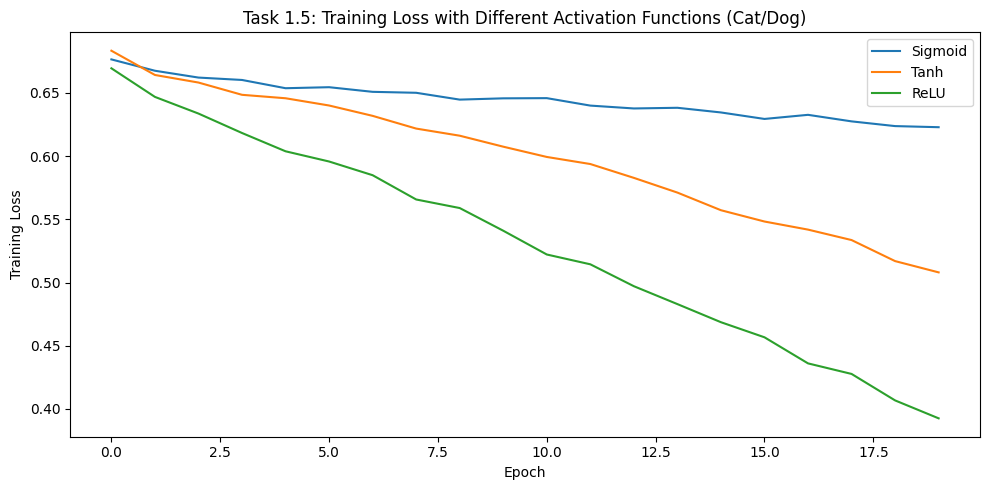


--- Cat/Dog Findings ---
Cat/dog task is harder than frog/ship - classes look more similar.
BatchNorm + Dropout significantly helps prevent overfitting.
Needed larger/deeper network compared to frog/ship task.
ReLU still converges fastest; Sigmoid struggles with vanishing gradients.


In [20]:
# Task 1.5: Improved network for cat/dog (>0.64 accuracy)
# Using BatchNorm and Dropout for better generalization

class CatDogNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_with_mode(model, train_loader, criterion, optimizer, num_epoch):
    epoch_losses = []
    for epoch in range(num_epoch):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            y = y.float().view(-1, 1)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {avg_loss:.4f}")
    return epoch_losses

criterion_cd = nn.BCELoss()
cat_dog_model = CatDogNet()
optimizer_cd = optim.Adam(cat_dog_model.parameters(), lr=0.001)

print("Training cat/dog model (with BatchNorm + Dropout)...")
cd_losses = train_with_mode(cat_dog_model, train_loader_cd, criterion_cd, optimizer_cd, num_epoch=50)

# Evaluate
cat_dog_model.eval()
cd_test_loss, cd_test_acc = evaluate(cat_dog_model, test_loader_cd, criterion_cd)
print(f"\nCat/Dog Test Loss: {cd_test_loss:.4f}, Test Accuracy: {cd_test_acc:.4f}")

# Experiment with activation functions for cat/dog (same architecture, 3 activations)
class CatDogNetAct(nn.Module):
    def __init__(self, act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 512),
            nn.BatchNorm1d(512),
            act,
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            act,
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

acts_cd = {'Sigmoid': nn.Sigmoid(), 'Tanh': nn.Tanh(), 'ReLU': nn.ReLU()}
all_cd_losses = {}
for act_name, act_fn in acts_cd.items():
    print(f"\nTraining cat/dog with {act_name}...")
    m = CatDogNetAct(act_fn)
    opt = optim.Adam(m.parameters(), lr=0.001)
    losses = train_with_mode(m, train_loader_cd, criterion_cd, opt, num_epoch=20)
    all_cd_losses[act_name] = losses

plt.figure(figsize=(10, 5))
for act_name, losses in all_cd_losses.items():
    plt.plot(losses, label=act_name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Task 1.5: Training Loss with Different Activation Functions (Cat/Dog)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Cat/Dog Findings ---")
print("Cat/dog task is harder than frog/ship - classes look more similar.")
print("BatchNorm + Dropout significantly helps prevent overfitting.")
print("Needed larger/deeper network compared to frog/ship task.")
print("ReLU still converges fastest; Sigmoid struggles with vanishing gradients.")

Great! Now that we've tried to solve binary classification on CIFAR-10 data, we'll switch to the task of **multi-class classification**. But before that, let's talk about the `Dataset` class in PyTorch.


#### BatchNorm

Now let us talk about a new type of network layer: batch normalization. This is a layer that helps make training more stable and faster. In addition, a neural network with batch normalization layers can often learn a task better than the same network without batch normalization.

Let us consider a neural network with several layers. Notice that layers 2–3 of this network can be viewed as a separate, smaller neural network. The input data for this smaller network are the outputs of the first layer.

We already know that, for better neural network training, the input data should be normalized. Therefore, normalizing the outputs of each intermediate layer also helps the network train better. BatchNorm is exactly the layer that performs this kind of normalization.

There is also a second reason to normalize the outputs of intermediate layers. This is the internal covariate shift effect in neural networks. Originally, BatchNorm was introduced as a way to eliminate this effect.

network.svg

What is internal covariate shift? Consider a neural network with several layers. During training, all layers are trained jointly. Each layer of the network must adapt to the values produced by the previous layer. However, during training, the distribution of values produced by each layer changes. As a result, at every iteration of the algorithm, each hidden layer has to adapt to a new distribution of outputs from the previous layer. This makes the network train more slowly. Moreover, the weights can change quite significantly at each training iteration, which may provoke other problems, such as exploding gradients.

Normalizing the outputs of the network layers would help solve this problem.

So, how can we implement normalization of layer outputs? The simplest idea is to strictly normalize the output of each layer before passing it further through the network, just as we normalize the input data. For example, we could force the mean of all layer outputs to be 0 and the variance to be 1.

But why not give the neural network more freedom and allow it to determine for itself how exactly it is best to normalize the outputs of each layer?

That is precisely the idea behind BatchNorm. BatchNorm is a trainable layer that normalizes network outputs using trainable parameters.


**A BatchNorm layer is applied after a network layer and works as follows:**

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Basically, BatchNorm shifts mean of each neuron's output in the current batch to $\beta$, and variance to $\gamma$.

However, in this setup we will have a problem on inference, when we should be able to compute network's predictions on a single element. If we have only one element in a batch, we can't reliably estimate mean and variance to apply BatchNorm. The idea of a fix here is the following: during inference, we will use statistics for $\mu_B$ and $\sigma^2_B$ that we have computed during training.

For this reason, BatchNorm behaves differently during training and during inference. **During training, BatchNorm will do the following:**

Initialize running mean $\mu_r$ and $\sigma_B$ as zero. Set *momentum* hyperparameter to some constant between 0 and 1.

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

Update the running mean and running variance:

$$\mu_r = (1-momentum)*\mu_r + momentum*\mu_B$$
$$\sigma_r = (1-momentum)*\sigma_r + momentum*\sigma_B$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Then we use $\mu_r$ and $\sigma_r$ during inference instead of batch-based statistics. So, **during inference BatchNorm does the following:**

1. Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_r}{\sigma_r}$$

3.	Compute the updated layer outputs using trained $\gamma$ and $\beta$ as

$$y_i = \gamma \widehat{x_i} + \beta$$



## Task 2. Dataset class


In the task above we worked with CIFAR-10 data that we loaded into NumPy/Pandas structures and then passed directly to dataloaders. In PyTorch there is a class called `Dataset` which allows us to work with data in a more flexible way. It lets us define custom transformations of the data before passing it into the model.

In this task you will need to define a `Dataset` class based on our CIFAR-10 data. We will then use it for training a neural network for multi-class classification of the whole CIFAR-10 dataset.


In [21]:
import torch
from torch.utils.data import Dataset, DataLoader

### Task 2.1 Implement `CIFAR10Dataset` class.


Your task is to fill in the blanks in the cell below. Please note the following:
- The `__init__` method usually stores the input data in class variables. In our case the data comes into `__init__` as a pandas DataFrame. To access elements by index faster in the `__getitem__` method, convert the data to `np.array` format inside `__init__`.
- If you want to apply transformations to the data before feeding it to the neural network (normalization, reshaping, etc.), this is usually done in the `__getitem__` method. We would like to normalize our images, i.e. bring all pixel values to the interval `[0, 1]`. To do this, divide all pixel values by `255.`. Note that normalization should be done in the `__getitem__` method, **not** in `__init__`. This is checked by asserts later and by the testing system when the task is submitted.
- Below you will train a neural network to classify CIFAR images into 10 classes using this Dataset class. You might experiment with other transformations to help your network fit better. For example, you might want to resize images before feeding them into the model or convert images into grayscale — this would lower number of image pixels by 3! Pillow library (https://pypi.org/project/pillow/) can help you with that. You will need first to reshape your image vector into 32x32x3, convert to Pilow Image format, resize/do other transformations, concert back to Numpy and flatten the image back into the vector. You can think of other transformations that might help.


**Note**: here we start to use all labels in CIFAR dataset, as below we will build a neural network for multi-class classification (all 10 CIFAR classes). So you don't need to select data elements with certain labels anymore.

In [22]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) — dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly

        # features
        self.X = data.drop(columns=['label']).values.astype(np.uint8)
        # target variable
        self.y = data['label'].values.astype(np.int64)

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        x = torch.tensor(self.X[idx] / 255.0, dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

Now we can define training and testing datasets. We'll do this for multi-class classification using the whole CIFAR-10 dataframe.


In [23]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)


The cell below checks that your Dataset class is implemented correctly


In [24]:
# check that types of self.X and self.y are np.array
assert type(cifar_train_dataset.X) == np.ndarray, "type of self.X in cifar_train_dataset is not np.array"
assert type(cifar_train_dataset.y) == np.ndarray, "type of self.y in cifar_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(cifar_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert float(torch.max(cifar_train_dataset[0][0])) <= 1.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert float(torch.min(cifar_train_dataset[0][0])) >= 0.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(cifar_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(cifar_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'


Great! After this we're ready to use our datasets. Now we can use `cifar_train_dataset` and `cifar_test_dataset` in `DataLoader`:


In [25]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


Now we will train and test our network for multi-class classification using these new dataloaders.


## Task 3. Multi-class classification with NNs


### Neural network for multi-class classification


We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:


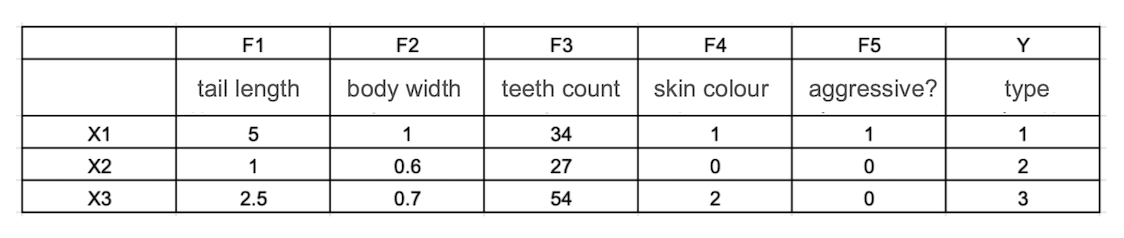


The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.


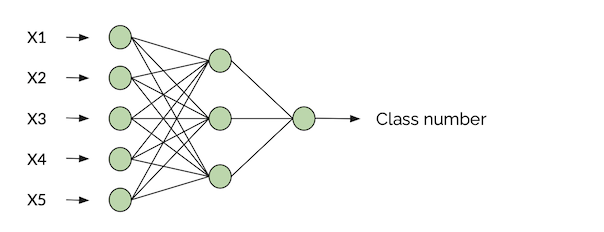


But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?


Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


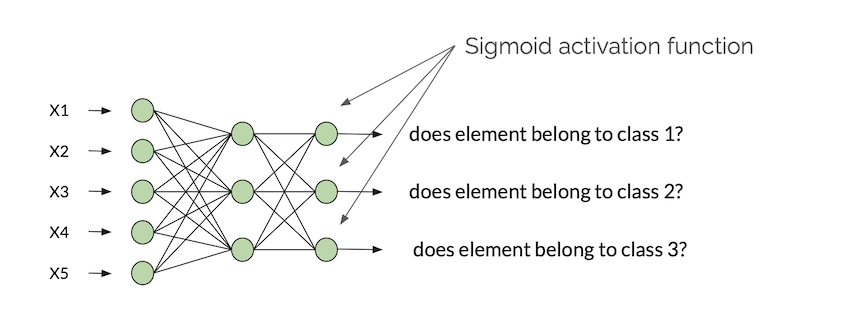


Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.


The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.


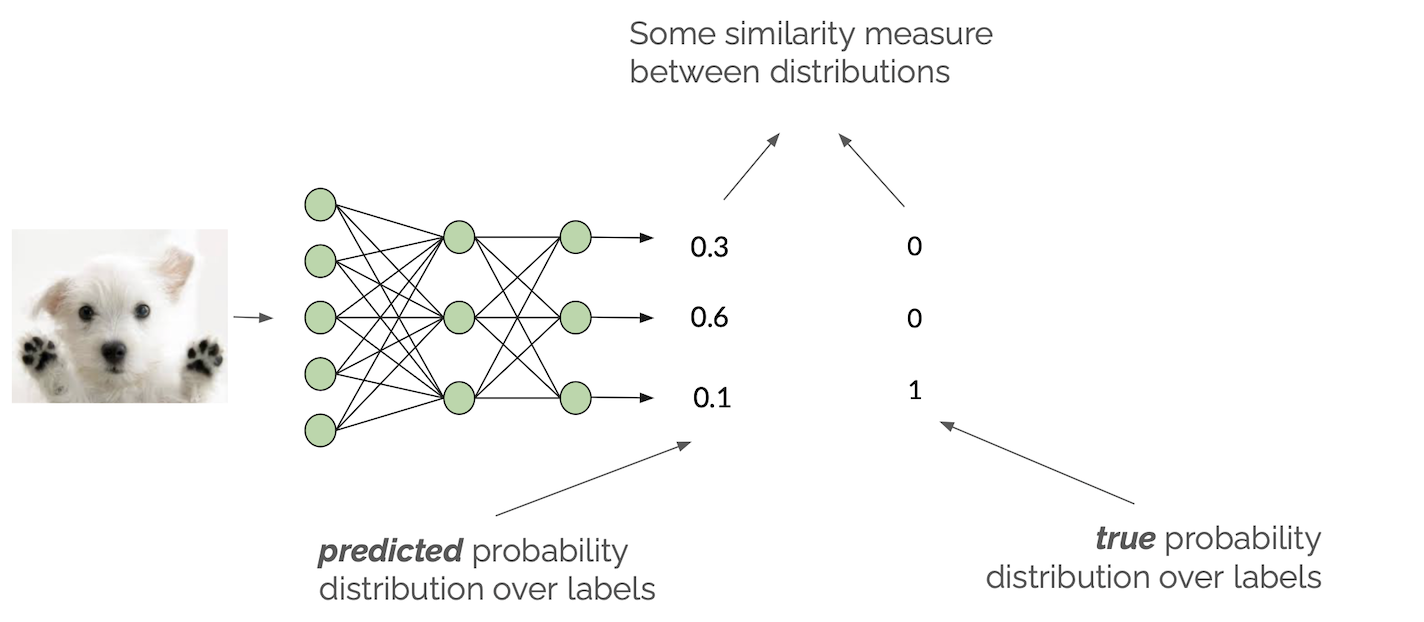


So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





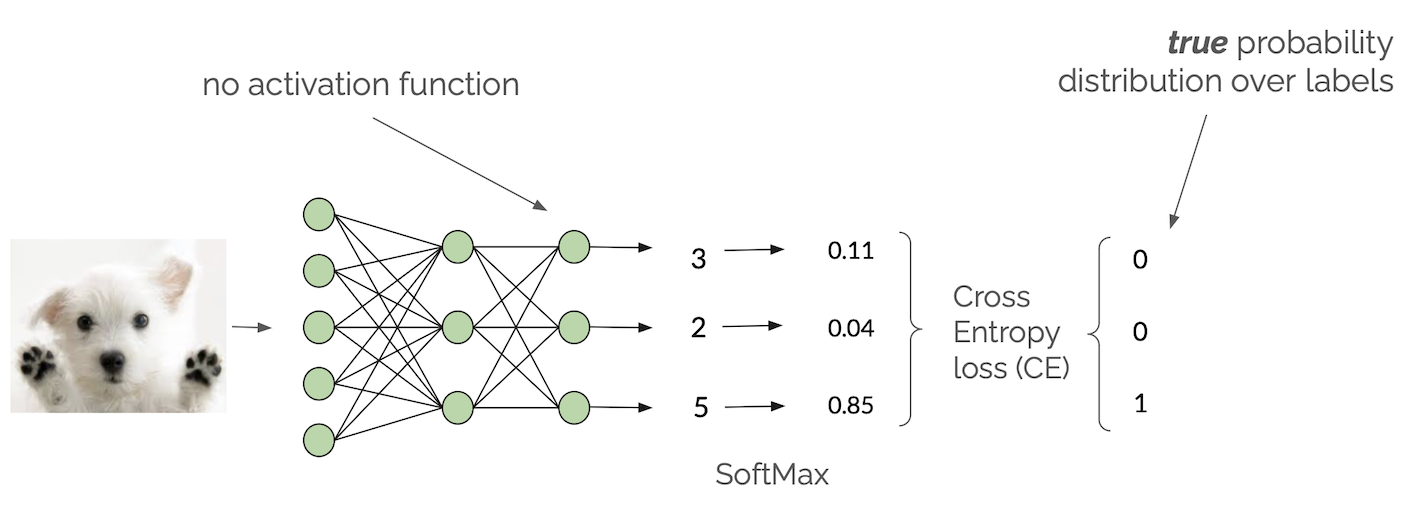


Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:


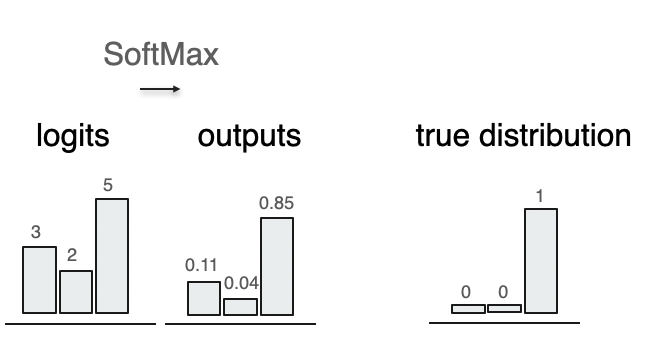


So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.


To sum up, if you are building neural network for $n$-class classification task with $n>2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.


### Task 3.1 Write a neural network for multi-class classification


Define a neural network that should solve a multi-class classification task with 10 classes on CIFAR-10. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [26]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Multi-class classification: 10 output classes for CIFAR-10
        self.fc1 = nn.Linear(3072, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)  # No softmax — CrossEntropyLoss expects logits
        return x

And create a network:


In [27]:
net = Net()


### Task 3.2 Define a train function


You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [28]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    model.train()
    epoch_losses = []
    for epoch in range(num_epoch):
        running_loss = 0.0
        for x, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epoch}", leave=False):
            # x is already normalized (from CIFAR10Dataset)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(dataloader)
        epoch_losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {avg_loss:.4f}")
    return model, epoch_losses

And let's define loss function, optimizer, dataloader and train our network. Use the full `cifar_train_dataset` here.


In [29]:
import torch.optim as optim

# loss function - CrossEntropyLoss for multi-class classification (expects logits)
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

# dataloader - use cifar_train_dataset (with normalization in __getitem__)
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)

# run training
net, losses = train(net, train_loader, criterion, optimizer, 60)

Epoch 1/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 3/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 4/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 5/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 6/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 7/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 8/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 9/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 10/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [10/60], Loss: 1.2396


Epoch 11/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 12/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 13/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 14/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 15/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 16/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 17/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 18/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 19/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 20/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [20/60], Loss: 1.0375


Epoch 21/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 22/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 23/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 24/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 25/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 26/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 27/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 28/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 29/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 30/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [30/60], Loss: 0.9081


Epoch 31/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 32/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 33/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 34/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 35/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 36/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 37/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 38/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 39/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 40/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [40/60], Loss: 0.8215


Epoch 41/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 42/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 43/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 44/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 45/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 46/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 47/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 48/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 49/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 50/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [50/60], Loss: 0.7366


Epoch 51/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 52/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 53/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 54/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 55/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 56/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 57/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 58/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 59/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 60/60:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch [60/60], Loss: 0.6867


### Task 3.3. Write a code for model evaluation


Again, you can borrow the code from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [30]:
from sklearn.metrics import accuracy_score

def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''
    model.eval()

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:
        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())

        # convert outputs of your network into class number (argmax for multi-class)
        y_pred = torch.argmax(y_pred, dim=1).tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = accuracy_score(y_true_list, y_pred_list)

    return np.mean(losses), accuracy

### Task 3.4 Train the neural network.


Here, again, your task is to improve the network so that it can achieve higher accuracy. Try to achieve **>0.53 accuracy** on the CIFAR-10 test part, but in general your goal is to improve as much as possible.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 128-512 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?
- Play with number of layers, numbers of neurons, and different activation functions
- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size
- As we've discussed above, play with data preprocessing in the Dataset class.

While you're doing experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


Multi-class Test Loss: 1.3268, Test Accuracy: 0.5748


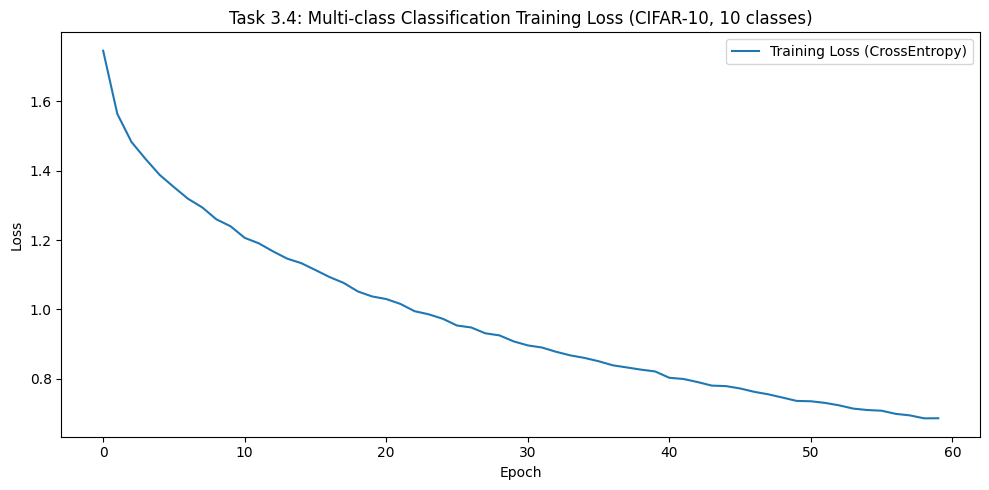


--- Multi-class Findings ---
Network: 3 hidden layers (512→256→128) + 10-output linear + BatchNorm + Dropout
CrossEntropyLoss expects raw logits (no softmax in network output)
ReLU activations with BatchNorm enables stable and fast convergence.
BatchNorm + Dropout reduces overfitting on the 10-class task.
Wider networks (more neurons per layer) help the 10-class task more than deeper ones.
Learning rate 0.001 with Adam optimizer gave stable training.


In [31]:
import matplotlib.pyplot as plt

# Task 3.4: Train and evaluate the multi-class network
# Use the test dataloader
test_loader_cifar = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)

net.eval()
test_loss_mc, test_acc_mc = evaluate(net, test_loader_cifar, criterion)
print(f"Multi-class Test Loss: {test_loss_mc:.4f}, Test Accuracy: {test_acc_mc:.4f}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss (CrossEntropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 3.4: Multi-class Classification Training Loss (CIFAR-10, 10 classes)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Multi-class Findings ---")
print("Network: 3 hidden layers (512→256→128) + 10-output linear + BatchNorm + Dropout")
print("CrossEntropyLoss expects raw logits (no softmax in network output)")
print("ReLU activations with BatchNorm enables stable and fast convergence.")
print("BatchNorm + Dropout reduces overfitting on the 10-class task.")
print("Wider networks (more neurons per layer) help the 10-class task more than deeper ones.")
print("Learning rate 0.001 with Adam optimizer gave stable training.")

That's it for the tasks in this notebook!
